In [ ]:
# ==============================================================================
# Global paths
#
# Assumption:
#   this notebook is located in BAGETI/case/
# ==============================================================================

# Project root = BAGETI/ 
# use your root
project_root <- "../../BAGETI"

# ------------------------------------------------------------------------------
# Main directories
# ------------------------------------------------------------------------------

script_dir <- file.path(
  project_root,
  "script"
)

data_dir <- file.path(
  project_root,
  "data"
)

case_dir <- file.path(
  project_root,
  "case"
)

spatial_dir <- file.path(
  data_dir,
  "HCC-3L",
  "spatial"
)

# All BAGETI results + downstream figures go here
output_dir <- file.path(
  case_dir,
  "HCC3_Barrier_myCAF"
)

# Aliases used by later blocks
bageti_dir <- output_dir
base_path  <- spatial_dir


# ------------------------------------------------------------------------------
# BAGETI source files
# ------------------------------------------------------------------------------

wrapper_file <- file.path(
  script_dir,
  "BAGETI_main.R"
)

cpp_file <- file.path(
  script_dir,
  "BAGETI.cpp"
)


# ------------------------------------------------------------------------------
# Input data
# ------------------------------------------------------------------------------

h5_path <- file.path(
  data_dir,
  "HCC-3L",
  "filtered_feature_bc_matrix.h5"
)

spatial_path <- file.path(
  spatial_dir,
  "tissue_positions_list.csv"
)

img_path <- file.path(
  spatial_dir,
  "tissue_hires_image.png"
)

scale_path <- file.path(
  spatial_dir,
  "scalefactors_json.json"
)


# ------------------------------------------------------------------------------
# Create output directory
# ------------------------------------------------------------------------------

if (!dir.exists(output_dir)) {
  dir.create(
    output_dir,
    recursive = TRUE
  )
}


# ------------------------------------------------------------------------------
# Check required files
# ------------------------------------------------------------------------------

required_input_files <- c(
  wrapper_file,
  cpp_file,
  h5_path,
  spatial_path,
  img_path,
  scale_path
)

missing_input_files <- required_input_files[
  !file.exists(required_input_files)
]

if (length(missing_input_files) > 0) {

  cat(
    "Missing input files:\n"
  )

  print(
    missing_input_files
  )

  stop(
    "Please check the project directory structure."
  )
}


cat(
  "Project root:",
  project_root,
  "\n"
)

cat(
  "Output directory:",
  output_dir,
  "\n"
)


source(
  wrapper_file
)

In [3]:
# ==============================================================================
# HCC Real Data Analysis with MRF-based Change Point Detection
# ==============================================================================

# 1. Load Libraries -----------------------------------------------------------
library(Seurat)
library(hdf5r)
library(Matrix)
library(doParallel)
library(foreach)
library(Rcpp)
library(RcppArmadillo)
library(ggplot2)
library(viridis)
library(gridExtra)
library(dplyr)
library(FNN)
library(tidyr)
library(patchwork)

# 2. Setup Paths & Source Files -----------------------------------------------

# 3. Data Loading & Preprocessing ---------------------------------------------
message("Loading HCC3 Data...")

# A. Read Counts
seurat_obj <- Read10X_h5(h5_path)
count_matrix <- as.matrix(seurat_obj)
count_matrix <- t(count_matrix) # Rows = Samples, Cols = Genes

# B. Read Spatial
spatial_coords <- read.csv(spatial_path, header = FALSE)
locations <- spatial_coords[, c(1, 6, 5)]
colnames(locations) <- c("barcode", "x", "y")
locations$y <- max(locations$y) - locations$y

# C. Filter & Align
count_barcodes <- rownames(count_matrix)
locations <- locations[locations$barcode %in% count_barcodes, ]
rownames(locations) <- locations$barcode
locations <- locations[count_barcodes, c("x", "y")]

message(sprintf("Total number of valid spatial locations (spots): %d", nrow(locations)))

# D. Normalize/Scale Coordinates -----------------
message("Starting Automatic Tilt Correction...")

# Helper function for tilt correction
find_optimal_tilt <- function(coords, range_deg = seq(-5, 5, by = 0.1)) {
  scores <- c()
  range_rad <- range_deg * (pi / 180)
  mat <- as.matrix(coords)
  for (theta in range_rad) {
    R <- matrix(c(cos(theta), -sin(theta), sin(theta), cos(theta)), 2, 2, byrow = TRUE)
    rot_coords <- mat %*% t(R)
    y_vals <- rot_coords[, 2]
    d <- density(y_vals, adjust = 0.5)
    scores <- c(scores, sum(d$y^2)) 
  }
  best_idx <- which.max(scores)
  return(list(angle = range_deg[best_idx], scores = scores))
}

opt_res <- find_optimal_tilt(locations[, c("x", "y")])
best_angle <- opt_res$angle
message(paste("  > Optimal correction angle found:", best_angle, "degrees"))

theta_fix <- best_angle * (pi / 180)
R_fix <- matrix(c(cos(theta_fix), -sin(theta_fix), sin(theta_fix), cos(theta_fix)), 2, 2, byrow = TRUE)

locations_corrected <- as.matrix(locations) %*% t(R_fix)
colnames(locations_corrected) <- c("x", "y")
locations <- as.data.frame(locations_corrected) 

# Calculate physical unit distance
nn_dist <- get.knn(locations, k = 1)$nn.dist
unit_dist <- median(nn_dist) 

# Scale and center
locations_scaled <- locations / unit_dist
locations_scaled$x <- locations_scaled$x - mean(locations_scaled$x)
locations_scaled$y <- locations_scaled$y - mean(locations_scaled$y)

raw_loc <- locations 
locations <- as.matrix(locations_scaled)

message(paste("Scaling complete. Median spot distance was", round(unit_dist, 2), "pixels."))

# ==============================================================================
# 0. Setup & Global Pre-processing
# ==============================================================================

# Define Gene Set
gene_sets_list <- list(
  Barrier_myCAF_plus = c(
    "ACTA2","TAGLN","MYL9","MYH11","TPM2","CTGF","COL1A2",
    "LRRC15","POSTN","COL1A1","COL3A1","THBS2"
  )
)

# Calculate global size factors (s) from the FULL matrix
message("Calculating global size factors (s) from FULL matrix...")
total_counts <- rowSums(count_matrix)
s_global <- total_counts / exp(mean(log(total_counts)))


Attaching package: ‘tidyr’


The following objects are masked from ‘package:Matrix’:

    expand, pack, unpack


Warning message:
“package ‘patchwork’ was built under R version 4.3.3”
Loading HCC3 Data...

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.2 GiB”
Total number of valid spatial locations (spots): 4758

Starting Automatic Tilt Correction...

  > Optimal correction angle found: 0 degrees

Scaling complete. Median spot distance was 200 pixels.

Calculating global size factors (s) from FULL matrix...



Preparing spatial expression plots...

Gene set 'Barrier_myCAF_plus': 12/12 genes found.



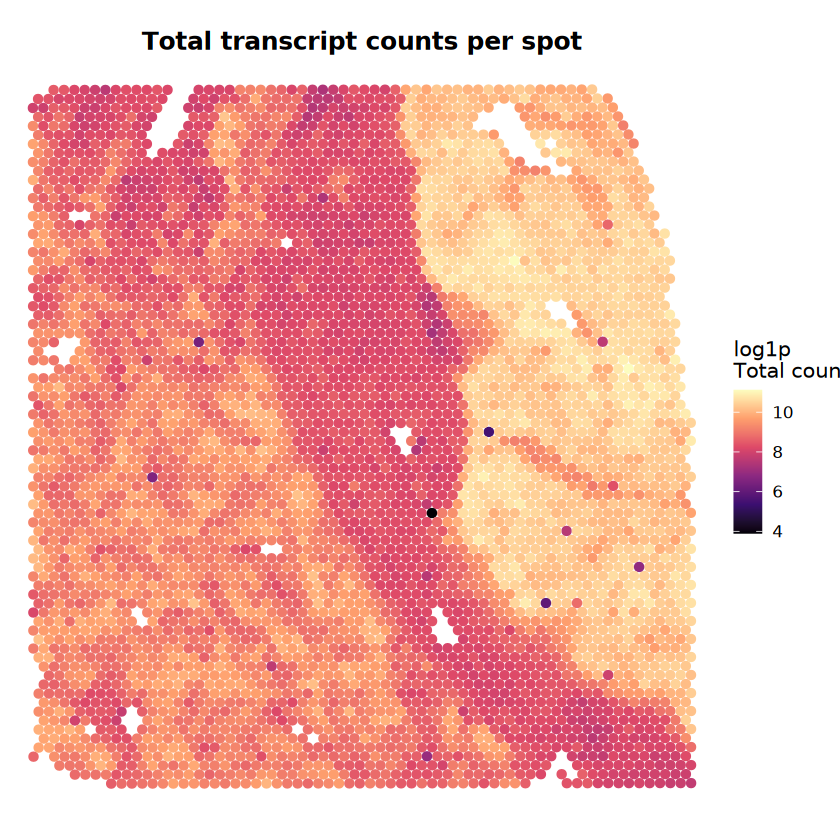

Spatial expression plots completed.



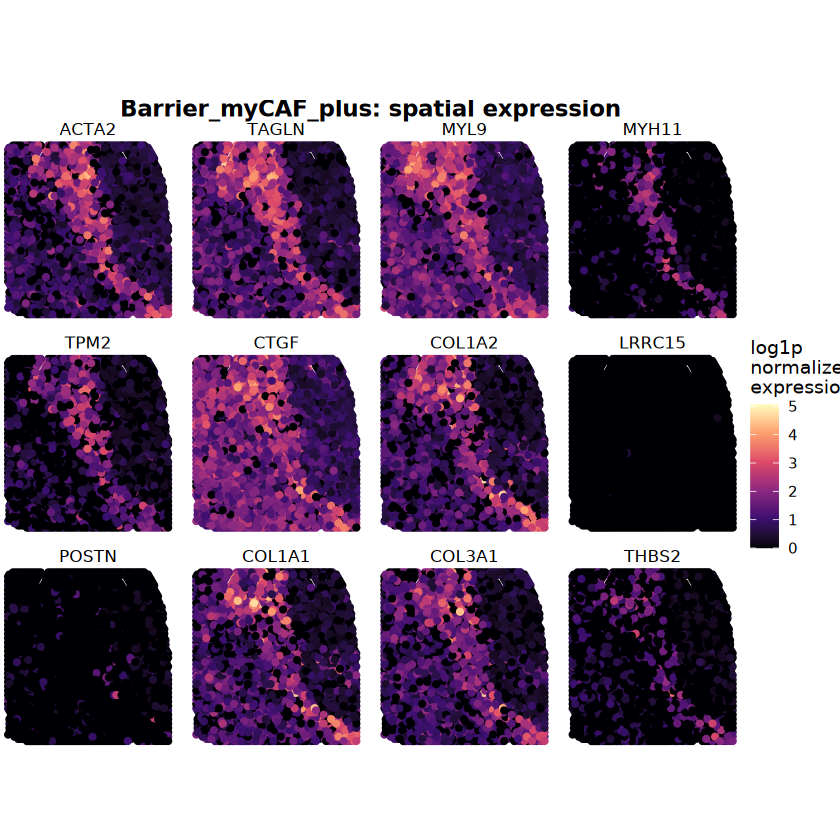

In [4]:
# ==============================================================================
# 1. Spatial visualization:
#    (A) Total counts per spot
#    (B) Expression of each gene in the selected gene set
# ==============================================================================

message("Preparing spatial expression plots...")

# ------------------------------------------------------------------------------
# A. Build spatial plotting dataframe
# ------------------------------------------------------------------------------

stopifnot(
  nrow(count_matrix) == nrow(locations),
  length(s_global) == nrow(count_matrix)
)

plot_df <- data.frame(
  barcode = rownames(count_matrix),
  x = locations[, "x"],
  y = locations[, "y"],
  total_counts = total_counts,
  detected_genes = rowSums(count_matrix > 0),
  s_global = s_global
)

# ------------------------------------------------------------------------------
# B. Plot total transcript counts / library size per spot
# ------------------------------------------------------------------------------

p_total <- ggplot(
  plot_df,
  aes(x = x, y = y, color = log1p(total_counts))
) +
  geom_point(size = 1.8) +
  coord_fixed() +
  scale_color_viridis_c(
    option = "magma",
    name = "log1p\nTotal counts"
  ) +
  labs(
    title = "Total transcript counts per spot",
    x = NULL,
    y = NULL
  ) +
  theme_void(base_size = 12) +
  theme(
    plot.title = element_text(
      hjust = 0.5,
      face = "bold"
    ),
    legend.position = "right"
  )

print(p_total)

ggsave(
  filename = file.path(output_dir, "spatial_total_counts.png"),
  plot = p_total,
  width = 6,
  height = 5,
  dpi = 300
)

# ------------------------------------------------------------------------------
# C. Extract selected gene set
# ------------------------------------------------------------------------------

gene_set_name <- "Barrier_myCAF_plus"
genes_requested <- gene_sets_list[[gene_set_name]]

# Keep genes actually present in the matrix
genes_present <- intersect(
  genes_requested,
  colnames(count_matrix)
)

genes_missing <- setdiff(
  genes_requested,
  colnames(count_matrix)
)

message(
  sprintf(
    "Gene set '%s': %d/%d genes found.",
    gene_set_name,
    length(genes_present),
    length(genes_requested)
  )
)

if (length(genes_missing) > 0) {
  message(
    "Missing genes: ",
    paste(genes_missing, collapse = ", ")
  )
}

if (length(genes_present) == 0) {
  stop("None of the selected genes were found in count_matrix.")
}

# ------------------------------------------------------------------------------
# D. Size-factor normalized expression
#
# expression_ij = count_ij / s_global_i
# plotted as log1p(expression_ij)
# ------------------------------------------------------------------------------

gene_expr_norm <- sweep(
  count_matrix[, genes_present, drop = FALSE],
  MARGIN = 1,
  STATS = s_global,
  FUN = "/"
)

gene_expr_log <- log1p(gene_expr_norm)

# Convert to long format for ggplot
gene_long <- data.frame(
  barcode = rownames(count_matrix),
  x = locations[, "x"],
  y = locations[, "y"],
  gene_expr_log,
  check.names = FALSE
) %>%
  pivot_longer(
    cols = all_of(genes_present),
    names_to = "gene",
    values_to = "expression"
  )

# Preserve requested gene ordering
gene_long$gene <- factor(
  gene_long$gene,
  levels = genes_present
)

# ------------------------------------------------------------------------------
# E. Faceted plot: every gene in the selected gene set
# ------------------------------------------------------------------------------

p_genes <- ggplot(
  gene_long,
  aes(x = x, y = y, color = expression)
) +
  geom_point(size = 1.25) +
  coord_fixed() +
  facet_wrap(
    ~ gene,
    ncol = 4
  ) +
  scale_color_viridis_c(
    option = "magma",
    name = "log1p\nnormalized\nexpression"
  ) +
  labs(
    title = paste0(
      gene_set_name,
      ": spatial expression"
    ),
    x = NULL,
    y = NULL
  ) +
  theme_void(base_size = 11) +
  theme(
    strip.text = element_text(
      face = "italic",
      size = 10
    ),
    plot.title = element_text(
      hjust = 0.5,
      face = "bold"
    ),
    legend.position = "right",
    panel.spacing = unit(0.5, "lines")
  )

print(p_genes)

ggsave(
  filename = file.path(
    output_dir,
    paste0(gene_set_name, "_all_genes_spatial.png")
  ),
  plot = p_genes,
  width = 12,
  height = 9,
  dpi = 300
)

message("Spatial expression plots completed.")

In [ ]:
# ==============================================================================
# 1. Main Loop for Each Gene Set
# ==============================================================================

# Helper function to extract CP results
extract_cp_data <- function(res, loc_data, label) {
  if(is.null(res) || is.null(res$cp_matrix)) return(NULL)
  cp_idx <- which(res$cp_matrix[, 1] == 1)
  if(length(cp_idx) == 0) return(NULL)
  data.frame(x = loc_data[cp_idx, "x"], y = loc_data[cp_idx, "y"], Type = label)
}

for (set_name in names(gene_sets_list)) {
  
  message(sprintf("\n=================================================="))
  message(sprintf("Processing Gene Set: %s", set_name))
  message(sprintf("=================================================="))
  
  # A. Match Genes (NO FILTERING APPLIED)
  target_genes <- gene_sets_list[[set_name]]
  target_indices <- match(target_genes, colnames(count_matrix))
  target_indices <- target_indices[!is.na(target_indices)]
  
  if(length(target_indices) == 0) {
    message(sprintf("WARNING: No genes found for set '%s'. Skipping...", set_name))
    next
  }
  
  # Subset matrix with exactly the matched genes
  count_matrix_sub <- count_matrix[, target_indices, drop = FALSE]
  valid_gene_names <- colnames(count_matrix_sub)
  
  message(sprintf("Using exactly %d matched genes: \n%s", 
                  length(valid_gene_names), paste(valid_gene_names, collapse = ", ")))
  
  gene_number_sub <- 1:ncol(count_matrix_sub)
  
  # C. Define Cluster Info
  cluster_info <- list(
    cluster_labels_origin = rep(1, length(gene_number_sub)), 
    cluster_labels        = rep(1L, length(gene_number_sub)) 
  )
  
  # D. Run RJMCMC across 3 directions
  directions <- c("row", "main diag", "minor diag")
  all_cp_dfs <- list()
  
  for(d in directions) {
    message(sprintf("  > Running direction: %s", d))
    
    tryCatch({
      res_d <- test_coefficient_multiple_mrf(
        count = count_matrix_sub,       
        gene_number = gene_number_sub,  
        manual_s = s_global,             
        
        loc = locations, 
        direction = d, 
        cp_distance = 3,
        cpp_file = cpp_file,
        n_chains = 2, n_iter = 3000, burnin = 1000, n_rb_cycles = 10,
        
        # Keep lambda slightly elevated to encourage finding clear boundaries
        lambda = 1.0, 
        
        mrf_alpha = 3.0, mrf_beta = 2.0, 
        mrf_bandwidth = 2.0, mrf_gamma = 1.0, mrf_method = "binary",
        
        cluster = cluster_info, 
        n_cores = 40 
      )
      
      df_d <- extract_cp_data(res_d, as.data.frame(locations), d)
      if(!is.null(df_d)) all_cp_dfs[[d]] <- df_d
      
      # Save full RDS object for potential diagnostics later
      saveRDS(res_d, file = file.path(output_dir, paste0(set_name, "_Full_Results_", d, ".rds")))
      
    }, error = function(e) {
      message(sprintf("    Error in direction %s: %s", d, e$message))
    })
  }
  
  # E. Merge Results
  if (length(all_cp_dfs) == 0) {
    message(sprintf("No change points detected for set '%s'.", set_name))
    next
  }
  
  df_joint <- do.call(rbind, all_cp_dfs)
  
  df_cpt_unique <- df_joint %>% 
    distinct(x, y, .keep_all = FALSE)
  
  # F. Prepare Plotting Data (Sum of the targeted gene set)
  subset_expr <- rowSums(count_matrix_sub)
  df_bg <- as.data.frame(locations)
  df_bg$expr <- subset_expr
  
  # G. Plot 1: Joint 3 Directions (Colored by sweeping direction)
  p_joint <- ggplot() +
    geom_point(data = df_bg, aes(x=x, y=y, color=expr), size = 0.5) +
    scale_color_viridis_c(option = "magma", name = "Sum Expr") +
    geom_point(data = df_joint, aes(x=x, y=y, fill=Type), shape=21, color="white", size = 2, stroke=0.2) +
    scale_fill_manual(values = c("row" = "cyan", "main diag" = "green", "minor diag" = "magenta")) +
    theme_minimal() + coord_fixed() +
    labs(title = paste0(set_name, ": Joint 3-Direction"), 
         subtitle = paste("Using all", length(valid_gene_names), "genes in the list"),
         x="Scaled X", y="Scaled Y")
  
  # H. Plot 2: Unified Red Dots (Final CP Map)
  p_unified <- ggplot() +
    geom_point(data = df_bg, aes(x=x, y=y, color=expr), size = 0.8, alpha = 0.8) +
    scale_color_viridis_c(option = "magma", name = "Sum Expr", direction = -1) +
    geom_point(data = df_cpt_unique, aes(x=x, y=y), 
               color = "red", size = 1.2, alpha = 0.8) +     
    theme_minimal() + coord_fixed() +
    labs(title = paste0(set_name, ": Unified Change Points"), 
         subtitle = paste("Total Unique CPs:", nrow(df_cpt_unique)),
         x = "Scaled X", y = "Scaled Y")
  
  # I. Save Outputs
  ggsave(filename = file.path(output_dir, paste0(set_name, "_Joint_Colors.png")), 
         plot = p_joint, width = 8, height = 6)
  
  ggsave(filename = file.path(output_dir, paste0(set_name, "_Unified_Red.png")), 
         plot = p_unified, width = 8, height = 6)
  
  saveRDS(df_joint, file = file.path(output_dir, paste0(set_name, "_CP_Data.rds")))
  saveRDS(df_bg, file = file.path(output_dir, paste0(set_name, "_Background_Expr.rds")))
  
  message(sprintf("Saved results for '%s' to %s", set_name, output_dir))
}

message("\nAll processing complete!")

Loading HCC3 Data...

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.2 GiB”
Total number of valid spatial locations (spots): 4758

Starting Automatic Tilt Correction...

  > Optimal correction angle found: 0 degrees

Scaling complete. Median spot distance was 200 pixels.

Calculating global size factors (s) from FULL matrix...



Processing Gene Set: Barrier_myCAF_plus


Using exactly 12 matched genes: 
ACTA2, TAGLN, MYL9, MYH11, TPM2, CTGF, COL1A2, LRRC15, POSTN, COL1A1, COL3A1, THBS2

  > Running direction: row

Using user-provided size factors.

Found 121 lines (segments) in direction 'row'

Red-Black Assignment (Inherited): 61 Red, 60 Black segments.


========== Red-Black Cycle 1/10 ==========

Updating RED lines (61 lines)...

Updating BLACK lines (60 lines)...

Completed cycle 1


========== Red-Black Cycle 2/10 ==========

Updating RED lines (61 lines)...

Updating BLACK lines (60 lines)...

Completed cycle 2


========== Red-Black Cyc

In [5]:
# ==============================================================================
# Reload previously saved BAGETI core results
# NO MCMC / BAGETI re-fitting is performed here
# ==============================================================================

library(dplyr)

set_name <- "Barrier_myCAF_plus"

directions <- c("row", "main diag", "minor diag")

# 1. Reload full BAGETI results
res_by_direction <- list()

for (d in directions) {
  res_file <- file.path(
    output_dir,
    paste0(set_name, "_Full_Results_", d, ".rds")
  )

  if (!file.exists(res_file)) {
    stop("Missing result file: ", res_file)
  }

  res_by_direction[[d]] <- readRDS(res_file)
}

res_row        <- res_by_direction[["row"]]
res_main_diag  <- res_by_direction[["main diag"]]
res_minor_diag <- res_by_direction[["minor diag"]]

# 2. Reload CP summary
cp_file <- file.path(output_dir, paste0(set_name, "_CP_Data.rds"))
df_joint <- readRDS(cp_file)

df_cpt_unique <- df_joint %>%
  distinct(x, y, .keep_all = FALSE)

# 3. Reload background coordinates / expression
bg_file <- file.path(output_dir, paste0(set_name, "_Background_Expr.rds"))
df_bg <- readRDS(bg_file)

cat("Reload complete.\n")
cat("Loaded objects:\n")
cat("  res_row\n")
cat("  res_main_diag\n")
cat("  res_minor_diag\n")
cat("  df_joint\n")
cat("  df_cpt_unique\n")
cat("  df_bg\n")

Reload complete.
Loaded objects:
  res_row
  res_main_diag
  res_minor_diag
  df_joint
  df_cpt_unique
  df_bg


H&E image: 1927 x 2000 
Hires scale factor: 0.1146789 
BAGETI background spots: 4758 
Matched spots: 4758 / 4758 

Affine mapping quality:


Warning message in summary.lm(fit_x):
“essentially perfect fit: summary may be unreliable”


R2 X: 1 


Warning message in summary.lm(fit_y):
“essentially perfect fit: summary may be unreliable”


R2 Y: 1 
2D mapping RMSE: 4.441395e-13 pixels
Reading direction: row 
Reading direction: main diag 
Reading direction: minor diag 

MAP primal edges: 473 

 main diag minor diag        row 
       110        179        184 

Dual edges: 473 
Maximum |primal dot dual|: 3.497203e-15 

HYSTERESIS CLEANING ON DUAL EDGES
Original dual edges: 473 
Median dual edge length: 0.5793387 
Support radius: 1.274545 
Grow radius: 1.04281 

Strong seed edges: 266 
Weak candidate edges: 381 
Edges retained after hysteresis: 316 

Boundary tracks after hysteresis:
# A tibble: 31 × 4
   component n_edges total_length n_directions
       <int>   <int>        <dbl>        <int>
 1        14      44        25.5             3
 2        23      41        23.8             3
 3         7      23        13.3             3
 4        19      22        12.7             3
 5        13      17         9.84            3
 6         4      13         7.53            3
 7        10      12         6.95            3
 8   

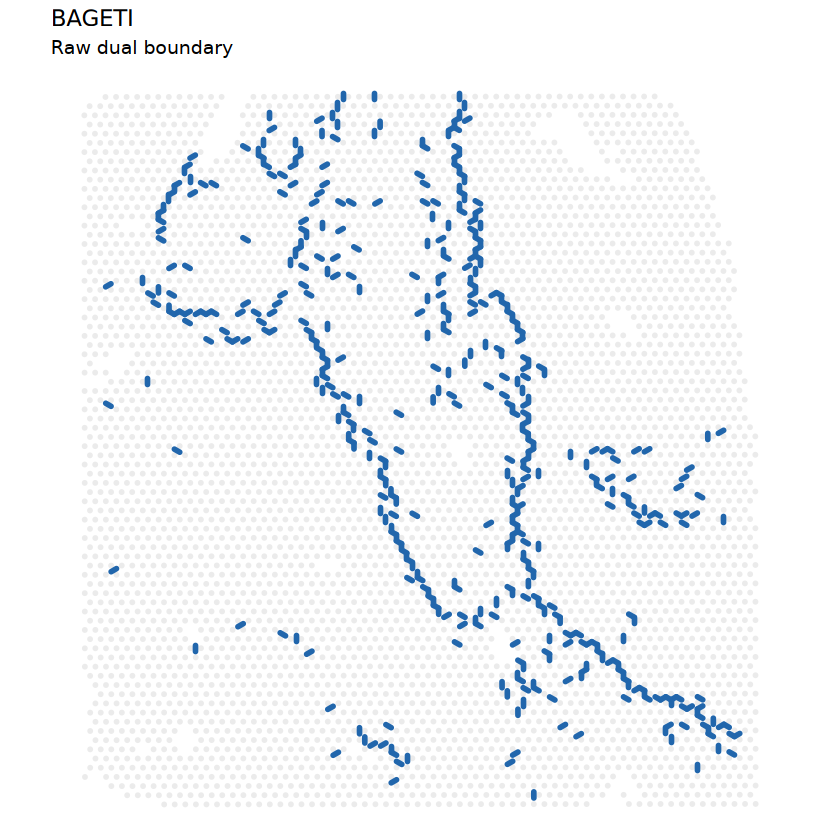


Cleaned dual edges mapped to H&E: 316 


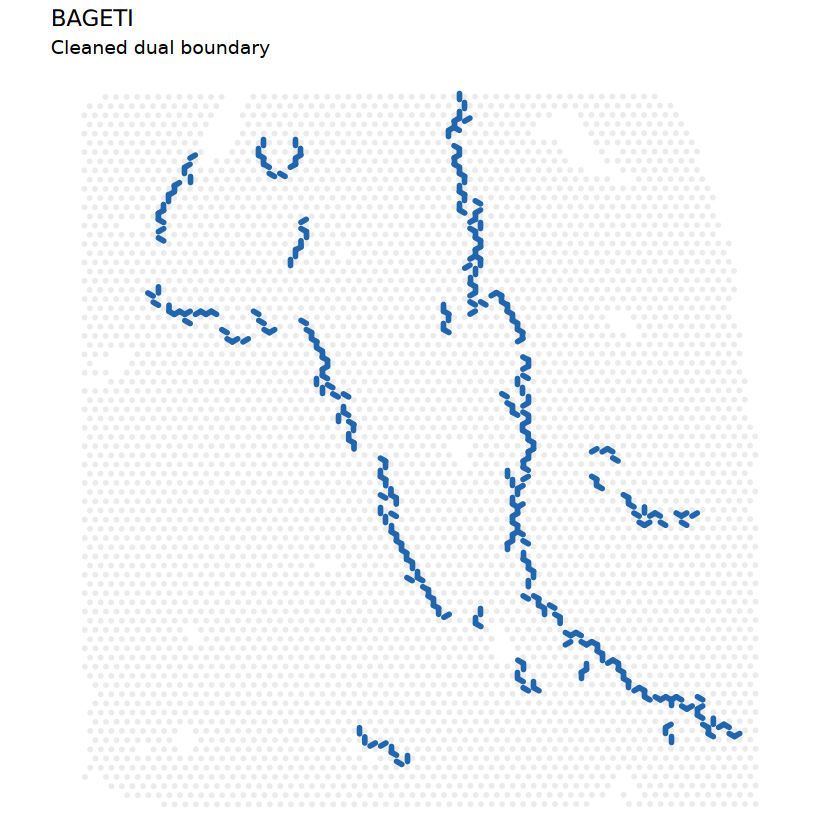


CLEANED DUAL BAGETI boundary completed.

Original MAP dual edges: 473 
Final cleaned dual edges: 316 

Clean boundary RDS:
 /work/cxz220015/Anaconda/BAGUTTE/case/Case HCC (827)/Barrier_myCAF_plus_Hysteresis_Boundary.rds 

H&E-coordinate RDS:
 /work/cxz220015/Anaconda/BAGUTTE/case/Case HCC (827)/Barrier_myCAF_plus_Hysteresis_Boundary_HEcoords.rds 

PNG:
 /work/cxz220015/Anaconda/BAGUTTE/case/Case HCC (827)/Barrier_myCAF_plus_Cleaned_Dual_Boundary_on_HE.png 

PDF:
 /work/cxz220015/Anaconda/BAGUTTE/case/Case HCC (827)/Barrier_myCAF_plus_Cleaned_Dual_Boundary_on_HE.pdf 


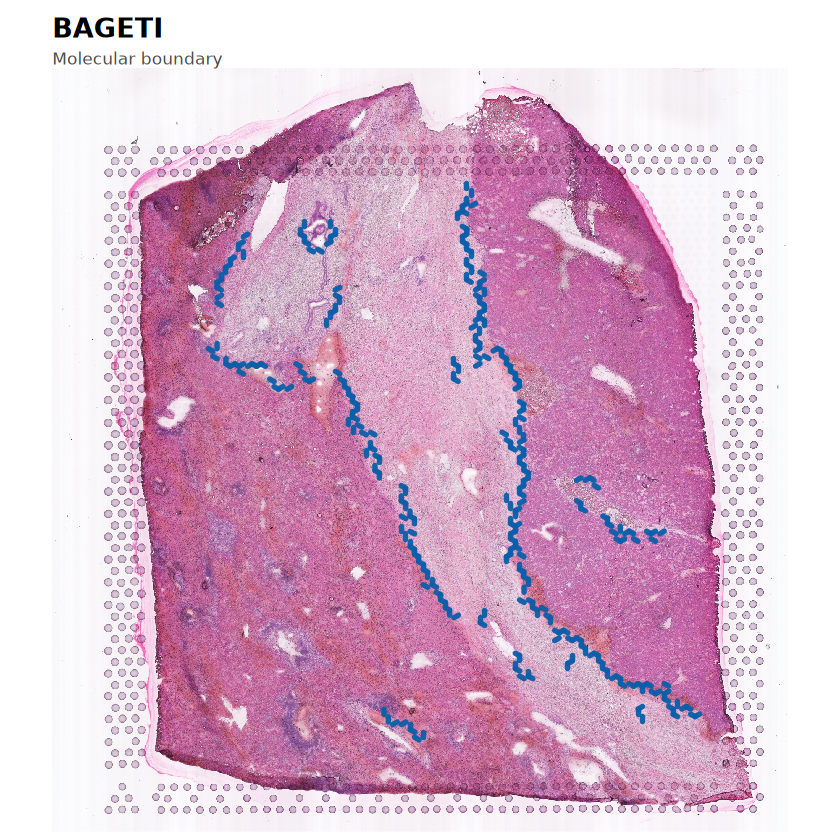

In [19]:
# ==============================================================================
# BAGETI:
# Block-2 results
#   -> MAP primal edges
#   -> DUAL/Voronoi edges
#   -> hysteresis / seed-and-grow cleaning
#   -> H&E overlay
#
# NO BAGETI / MCMC rerun.
# NO historical Edges_Data.rds required.
# NO historical Hysteresis_Boundary.rds required.
# ==============================================================================

library(dplyr)
library(ggplot2)
library(png)
library(jsonlite)
library(readr)


# ==============================================================================
# 1. Paths
# ==============================================================================


# ==============================================================================
# 2. Input files
# ==============================================================================

bg_file <- file.path(
  bageti_dir,
  paste0(
    set_name,
    "_Background_Expr.rds"
  )
)

result_files <- file.path(
  bageti_dir,
  paste0(
    set_name,
    "_Full_Results_",
    directions,
    ".rds"
  )
)

required_files <- c(
  img_path,
  scale_path,
  spatial_path,
  bg_file,
  result_files
)

missing_files <- required_files[
  !file.exists(required_files)
]

if (length(missing_files) > 0) {

  cat("Missing files:\n")
  print(missing_files)

  stop(
    "Required input files are missing."
  )
}


# ==============================================================================
# 3. Load H&E image
# ==============================================================================

img <- readPNG(
  img_path
)

img_w <- ncol(img)
img_h <- nrow(img)

scales <- fromJSON(
  scale_path
)

scale_factor <-
  scales$tissue_hires_scalef

cat(
  "H&E image:",
  img_w,
  "x",
  img_h,
  "\n"
)

cat(
  "Hires scale factor:",
  scale_factor,
  "\n"
)


# ==============================================================================
# 4. Load original 10x spatial coordinates
# ==============================================================================

coords <- read_csv(
  spatial_path,
  col_names = FALSE,
  show_col_types = FALSE
)

colnames(coords) <- c(
  "barcode",
  "in_tissue",
  "array_row",
  "array_col",
  "pxl_row_in_fullres",
  "pxl_col_in_fullres"
)

coords <- coords %>%
  mutate(

    x_img =
      pxl_col_in_fullres *
      scale_factor,

    y_img =
      pxl_row_in_fullres *
      scale_factor
  )


# ==============================================================================
# 5. Load BAGETI background coordinates
# ==============================================================================

df_bg <- readRDS(
  bg_file
)

if (!all(c("x", "y") %in% names(df_bg))) {

  stop(
    "Background_Expr.rds must contain x and y."
  )
}


# Recover barcode from row names if necessary
if (!"barcode" %in% names(df_bg)) {

  rn <- rownames(
    df_bg
  )

  if (
    is.null(rn) ||
    all(
      rn ==
        as.character(
          seq_len(
            nrow(df_bg)
          )
        )
    )
  ) {

    stop(
      paste0(
        "df_bg has no usable barcode column ",
        "or barcode rownames."
      )
    )
  }

  df_bg$barcode <- rn
}

cat(
  "BAGETI background spots:",
  nrow(df_bg),
  "\n"
)


# ==============================================================================
# 6. Match BAGETI coordinates to H&E
# ==============================================================================

idx <- match(
  df_bg$barcode,
  coords$barcode
)

df_map <- df_bg %>%
  mutate(

    x_img =
      coords$x_img[idx],

    y_img =
      coords$y_img[idx],

    matched =
      !is.na(idx)
  )

cat(
  "Matched spots:",
  sum(df_map$matched),
  "/",
  nrow(df_map),
  "\n"
)


# ==============================================================================
# 7. Fit BAGETI -> H&E affine transformation
# ==============================================================================

map_fit <- df_map %>%
  filter(
    matched,
    is.finite(x),
    is.finite(y),
    is.finite(x_img),
    is.finite(y_img)
  )

fit_x <- lm(
  x_img ~ x + y,
  data = map_fit
)

fit_y <- lm(
  y_img ~ x + y,
  data = map_fit
)

cat(
  "\nAffine mapping quality:\n"
)

cat(
  "R2 X:",
  summary(fit_x)$r.squared,
  "\n"
)

cat(
  "R2 Y:",
  summary(fit_y)$r.squared,
  "\n"
)

map_fit$pred_x <- predict(
  fit_x,
  newdata = map_fit
)

map_fit$pred_y <- predict(
  fit_y,
  newdata = map_fit
)

mapping_rmse <- sqrt(
  mean(
    (map_fit$pred_x - map_fit$x_img)^2 +
      (map_fit$pred_y - map_fit$y_img)^2
  )
)

cat(
  "2D mapping RMSE:",
  mapping_rmse,
  "pixels\n"
)


# ==============================================================================
# 8. Extract MAP PRIMAL edges
# ==============================================================================

extract_main_edges <- function(
    res,
    loc_data,
    label) {

  if (
    is.null(res) ||
    is.null(res$line_results)
  ) {
    return(NULL)
  }

  edge_list <- list()

  for (i in seq_along(res$line_results)) {

    line_res <-
      res$line_results[[i]]

    if (
      is.null(line_res) ||
      is.null(line_res$final_cp_details)
    ) {
      next
    }

    for (
      c in seq_along(
        line_res$final_cp_details
      )
    ) {

      cp_block <-
        line_res$final_cp_details[[c]]

      if (
        is.null(cp_block) ||
        is.null(cp_block$details)
      ) {
        next
      }

      for (cp_info in cp_block$details) {

        e <- cp_info$edge_global

        if (
          is.null(e) ||
          length(e) != 2
        ) {
          next
        }

        e <- as.integer(e)

        if (
          any(!is.finite(e)) ||
          any(e < 1L) ||
          any(e > nrow(loc_data))
        ) {
          next
        }

        edge_list[[length(edge_list) + 1L]] <-
          data.frame(

            x =
              loc_data[e[1], "x"],

            y =
              loc_data[e[1], "y"],

            xend =
              loc_data[e[2], "x"],

            yend =
              loc_data[e[2], "y"],

            spot1 =
              e[1],

            spot2 =
              e[2],

            Type =
              label,

            stringsAsFactors =
              FALSE
          )
      }
    }
  }

  if (length(edge_list) == 0) {
    return(NULL)
  }

  bind_rows(
    edge_list
  )
}


# ==============================================================================
# 9. Extract MAP primal edges from all 3 directions
# ==============================================================================

main_edge_list <- list()

for (d in directions) {

  res_file <- file.path(
    bageti_dir,
    paste0(
      set_name,
      "_Full_Results_",
      d,
      ".rds"
    )
  )

  cat(
    "Reading direction:",
    d,
    "\n"
  )

  res_d <- readRDS(
    res_file
  )

  tmp <- extract_main_edges(
    res = res_d,
    loc_data = df_bg,
    label = d
  )

  if (!is.null(tmp)) {

    main_edge_list[[d]] <-
      tmp
  }
}

if (length(main_edge_list) == 0) {

  stop(
    "No BAGETI MAP edges were extracted."
  )
}

df_main_primal <- bind_rows(
  main_edge_list
)

cat(
  "\nMAP primal edges:",
  nrow(df_main_primal),
  "\n"
)

print(
  table(
    df_main_primal$Type
  )
)


# ==============================================================================
# 10. Convert PRIMAL -> DUAL/Voronoi boundary
# ==============================================================================

df_main_dual <- df_main_primal %>%

  mutate(

    dx =
      xend - x,

    dy =
      yend - y,

    primal_length =
      sqrt(
        dx^2 +
        dy^2
      ),

    mid_x =
      (x + xend) / 2,

    mid_y =
      (y + yend) / 2
  ) %>%

  filter(
    is.finite(
      primal_length
    ),
    primal_length > 1e-10
  ) %>%

  mutate(

    # perpendicular unit vector
    perp_x =
      -dy /
      primal_length,

    perp_y =
      dx /
      primal_length,

    # Voronoi shared-edge length
    dual_length =
      primal_length /
      sqrt(3),

    half_dual =
      dual_length / 2,

    # dual endpoints
    bx1 =
      mid_x -
      half_dual *
      perp_x,

    by1 =
      mid_y -
      half_dual *
      perp_y,

    bx2 =
      mid_x +
      half_dual *
      perp_x,

    by2 =
      mid_y +
      half_dual *
      perp_y
  )


# ==============================================================================
# 11. Check primal-dual geometry
# ==============================================================================

dot_product <- with(
  df_main_dual,

  (xend - x) *
    (bx2 - bx1) +

    (yend - y) *
    (by2 - by1)
)

cat(
  "\nDual edges:",
  nrow(df_main_dual),
  "\n"
)

cat(
  "Maximum |primal dot dual|:",
  max(
    abs(dot_product),
    na.rm = TRUE
  ),
  "\n"
)


# ==============================================================================
# 12. HYSTERESIS / SEED-AND-GROW CLEANING ON DUAL EDGES
# ==============================================================================

df_seg <- df_main_dual %>%
  mutate(

    segment_id =
      seq_len(n()),

    mid_x =
      (bx1 + bx2) / 2,

    mid_y =
      (by1 + by2) / 2,

    segment_length =
      sqrt(
        (bx2 - bx1)^2 +
        (by2 - by1)^2
      )
  )

if (nrow(df_seg) == 0) {

  stop(
    "No dual segments available."
  )
}


median_edge_length <- median(
  df_seg$segment_length,
  na.rm = TRUE
)

cat(
  "\n============================================\n"
)

cat(
  "HYSTERESIS CLEANING ON DUAL EDGES\n"
)

cat(
  "============================================\n"
)

cat(
  "Original dual edges:",
  nrow(df_seg),
  "\n"
)

cat(
  "Median dual edge length:",
  median_edge_length,
  "\n"
)


# ------------------------------------------------------------------------------
# 12.1 Midpoint distance matrix
# ------------------------------------------------------------------------------

mid_mat <- as.matrix(
  df_seg[
    ,
    c(
      "mid_x",
      "mid_y"
    )
  ]
)

D <- as.matrix(
  dist(
    mid_mat
  )
)


# ------------------------------------------------------------------------------
# 12.2 Spatial scales
# SAME AS ORIGINAL CLEANING BLOCK
# ------------------------------------------------------------------------------

support_radius <-
  2.2 *
  median_edge_length

grow_radius <-
  1.8 *
  median_edge_length


cat(
  "Support radius:",
  support_radius,
  "\n"
)

cat(
  "Grow radius:",
  grow_radius,
  "\n"
)


# ------------------------------------------------------------------------------
# 12.3 Local support
# ------------------------------------------------------------------------------

local_n <- integer(
  nrow(df_seg)
)

local_direction_n <- integer(
  nrow(df_seg)
)


for (i in seq_len(nrow(df_seg))) {

  idx_local <- which(
    D[i, ] <=
      support_radius
  )

  idx_local <- setdiff(
    idx_local,
    i
  )

  local_n[i] <-
    length(
      idx_local
    )


  if (
    "Type" %in%
      colnames(df_seg) &&
    length(idx_local) > 0
  ) {

    local_direction_n[i] <-
      length(
        unique(
          c(
            df_seg$Type[i],
            df_seg$Type[idx_local]
          )
        )
      )

  } else {

    local_direction_n[i] <-
      1L
  }
}


df_seg$local_n <-
  local_n

df_seg$local_direction_n <-
  local_direction_n


# ------------------------------------------------------------------------------
# 12.4 Strong seeds + weak candidates
# SAME RULE AS ORIGINAL CLEANING
# ------------------------------------------------------------------------------

df_seg <- df_seg %>%
  mutate(

    strong =
      (
        local_direction_n >= 2 &
        local_n >= 2
      ) |
      (
        local_n >= 5
      ),

    weak =
      local_n >= 1
  )


cat(
  "\nStrong seed edges:",
  sum(
    df_seg$strong
  ),
  "\n"
)

cat(
  "Weak candidate edges:",
  sum(
    df_seg$weak
  ),
  "\n"
)


# ------------------------------------------------------------------------------
# 12.5 Proximity graph
# ------------------------------------------------------------------------------

adj <- (
  D <=
    grow_radius
)

diag(adj) <-
  FALSE


# ------------------------------------------------------------------------------
# 12.6 Seed-and-grow
# ------------------------------------------------------------------------------

keep <- rep(
  FALSE,
  nrow(df_seg)
)

strong_idx <- which(
  df_seg$strong
)

queue <-
  strong_idx

keep[
  strong_idx
] <- TRUE


while (length(queue) > 0) {

  node <-
    queue[1]

  if (length(queue) == 1) {

    queue <-
      integer(0)

  } else {

    queue <-
      queue[-1]
  }


  neighbors <- which(
    adj[node, ] &
      df_seg$weak
  )


  new_nodes <- neighbors[
    !keep[neighbors]
  ]


  if (
    length(new_nodes) > 0
  ) {

    keep[
      new_nodes
    ] <- TRUE

    queue <- c(
      queue,
      new_nodes
    )
  }
}


df_seg$keep_hysteresis <-
  keep


cat(
  "Edges retained after hysteresis:",
  sum(
    df_seg$keep_hysteresis
  ),
  "\n"
)


# ------------------------------------------------------------------------------
# 12.7 Connected components after hysteresis
# ------------------------------------------------------------------------------

idx_keep <- which(
  df_seg$keep_hysteresis
)

component <- rep(
  NA_integer_,
  nrow(df_seg)
)

current_component <-
  0L


for (start in idx_keep) {

  if (
    !is.na(
      component[start]
    )
  ) {
    next
  }


  current_component <-
    current_component +
    1L

  component[start] <-
    current_component

  queue <-
    start


  while (
    length(queue) > 0
  ) {

    node <-
      queue[1]

    if (
      length(queue) == 1
    ) {

      queue <-
        integer(0)

    } else {

      queue <-
        queue[-1]
    }


    neighbors <- which(
      adj[node, ] &
        df_seg$keep_hysteresis
    )


    new_nodes <- neighbors[
      is.na(
        component[
          neighbors
        ]
      )
    ]


    if (
      length(new_nodes) > 0
    ) {

      component[
        new_nodes
      ] <- current_component

      queue <- c(
        queue,
        new_nodes
      )
    }
  }
}


df_seg$component <-
  component


# ------------------------------------------------------------------------------
# 12.8 Summarize retained boundary tracks
# ------------------------------------------------------------------------------

component_summary <- df_seg %>%

  filter(
    keep_hysteresis,
    !is.na(component)
  ) %>%

  group_by(
    component
  ) %>%

  summarise(

    n_edges =
      n(),

    total_length =
      sum(
        segment_length,
        na.rm = TRUE
      ),

    n_directions =
      n_distinct(
        Type
      ),

    .groups =
      "drop"
  ) %>%

  arrange(
    desc(
      n_edges
    )
  )


cat(
  "\nBoundary tracks after hysteresis:\n"
)

print(
  component_summary,
  n = Inf
)


# ------------------------------------------------------------------------------
# 12.9 Remove only tiny residual components
# SAME AS ORIGINAL:
# keep tracks with >= 3 edges
# ------------------------------------------------------------------------------

min_track_edges <-
  3L


keep_components <- component_summary %>%

  filter(
    n_edges >=
      min_track_edges
  ) %>%

  pull(
    component
  )


df_boundary_final <- df_seg %>%

  filter(
    keep_hysteresis,
    component %in%
      keep_components
  )


cat(
  "\nOriginal dual edges:",
  nrow(df_seg),
  "\n"
)

cat(
  "Final cleaned dual edges:",
  nrow(df_boundary_final),
  "\n"
)

cat(
  "Removed dual edges:",
  nrow(df_seg) -
    nrow(df_boundary_final),
  "\n"
)


# ==============================================================================
# 13. Save CLEANED dual boundary in BAGETI coordinates
# ==============================================================================

clean_boundary_file <- file.path(
  output_dir,
  paste0(
    set_name,
    "_Hysteresis_Boundary.rds"
  )
)

saveRDS(
  df_boundary_final,
  clean_boundary_file
)

cat(
  "\nSaved cleaned dual boundary:\n",
  clean_boundary_file,
  "\n"
)

# ==============================================================================
# 13.5 Diagnostic plot: RAW dual boundary BEFORE cleaning
# ==============================================================================

p_raw_dual <- ggplot() +

  geom_point(
    data = df_bg,
    aes(
      x = x,
      y = y
    ),
    color = "grey92",
    size = 0.6
  ) +

  geom_segment(
    data = df_main_dual,
    aes(
      x = bx1,
      y = by1,
      xend = bx2,
      yend = by2
    ),
    color = "#2166AC",
    linewidth = 1.2,
    lineend = "round"
  ) +

  coord_fixed() +

  theme_void() +

  labs(
    title = "BAGETI",
    subtitle = "Raw dual boundary"
  )

print(p_raw_dual)


# Optional save
out_raw_dual_png <- file.path(
  output_dir,
  paste0(
    set_name,
    "_Raw_Dual_Boundary.png"
  )
)

out_raw_dual_pdf <- file.path(
  output_dir,
  paste0(
    set_name,
    "_Raw_Dual_Boundary.pdf"
  )
)

ggsave(
  filename = out_raw_dual_png,
  plot = p_raw_dual,
  width = 8,
  height = 8,
  dpi = 400,
  bg = "white"
)

ggsave(
  filename = out_raw_dual_pdf,
  plot = p_raw_dual,
  width = 8,
  height = 8,
  bg = "white"
)

cat(
  "\nSaved raw dual boundary plot:\n",
  out_raw_dual_png,
  "\n",
  out_raw_dual_pdf,
  "\n"
)

# ==============================================================================
# 14. Diagnostic plot before H&E mapping
# ==============================================================================

p_clean_dual <- ggplot() +

  geom_point(
    data = df_bg,
    aes(
      x = x,
      y = y
    ),
    color = "grey92",
    size = 0.6
  ) +

  geom_segment(
    data = df_boundary_final,
    aes(
      x = bx1,
      y = by1,
      xend = bx2,
      yend = by2
    ),
    color = "#2166AC",
    linewidth = 1.2,
    lineend = "round"
  ) +

  coord_fixed() +

  theme_void() +

  labs(
    title =
      "BAGETI",
    subtitle =
      "Cleaned dual boundary"
  )

print(
  p_clean_dual
)


# ==============================================================================
# 15. Helper: BAGETI coordinates -> H&E
# ==============================================================================

transform_to_he <- function(
    x,
    y) {

  new_df <- data.frame(
    x = x,
    y = y
  )

  data.frame(

    x_img =
      predict(
        fit_x,
        newdata =
          new_df
      ),

    y_img =
      predict(
        fit_y,
        newdata =
          new_df
      )
  )
}


# ==============================================================================
# 16. Transform CLEANED dual endpoints -> H&E
# ==============================================================================

p1 <- transform_to_he(
  df_boundary_final$bx1,
  df_boundary_final$by1
)

p2 <- transform_to_he(
  df_boundary_final$bx2,
  df_boundary_final$by2
)


df_boundary_he <- df_boundary_final %>%

  mutate(

    hx1 =
      p1$x_img,

    hy1 =
      p1$y_img,

    hx2 =
      p2$x_img,

    hy2 =
      p2$y_img
  ) %>%

  filter(
    is.finite(hx1),
    is.finite(hy1),
    is.finite(hx2),
    is.finite(hy2)
  )


cat(
  "\nCleaned dual edges mapped to H&E:",
  nrow(df_boundary_he),
  "\n"
)


# ==============================================================================
# 17. Save H&E-coordinate cleaned boundary
# ==============================================================================

out_boundary_rds <- file.path(
  output_dir,
  paste0(
    set_name,
    "_Hysteresis_Boundary_HEcoords.rds"
  )
)

saveRDS(
  df_boundary_he,
  out_boundary_rds
)


# ==============================================================================
# 18. H&E + CLEANED DUAL boundary
# ==============================================================================

p_he_clean <- ggplot() +

  annotation_raster(
    img,

    xmin = 0,
    xmax = img_w,

    ymin = 0,
    ymax = img_h
  ) +

  geom_segment(
    data =
      df_boundary_he,

    aes(
      x = hx1,
      y = hy1,
      xend = hx2,
      yend = hy2
    ),

    color =
      "#0B5EA8",

    linewidth =
      1.15,

    alpha =
      0.95,

    lineend =
      "round"
  ) +

  scale_x_continuous(

    limits =
      c(
        0,
        img_w
      ),

    expand =
      c(
        0,
        0
      )
  ) +

  scale_y_reverse(

    limits =
      c(
        img_h,
        0
      ),

    expand =
      c(
        0,
        0
      )
  ) +

  coord_fixed() +

  theme_void() +

  theme(

    plot.title =
      element_text(
        face = "bold",
        size = 16,
        hjust = 0
      ),

    plot.subtitle =
      element_text(
        size = 10,
        color = "grey30",
        hjust = 0
      ),

    plot.margin =
      margin(
        5,
        5,
        5,
        5
      )
  ) +

  labs(

    title =
      "BAGETI",

    subtitle =
      "Molecular boundary"
  )


# ==============================================================================
# 19. Display
# ==============================================================================

print(
  p_he_clean
)


# ==============================================================================
# 20. Save PNG + PDF
# ==============================================================================

out_png <- file.path(
  output_dir,
  paste0(
    set_name,
    "_Cleaned_Dual_Boundary_on_HE.png"
  )
)

out_pdf <- file.path(
  output_dir,
  paste0(
    set_name,
    "_Cleaned_Dual_Boundary_on_HE.pdf"
  )
)


ggsave(
  filename =
    out_png,

  plot =
    p_he_clean,

  width =
    8,

  height =
    8,

  dpi =
    400,

  bg =
    "white"
)


ggsave(
  filename =
    out_pdf,

  plot =
    p_he_clean,

  width =
    8,

  height =
    8,

  bg =
    "white"
)


# ==============================================================================
# 21. Summary
# ==============================================================================

cat(
  "\n====================================================\n"
)

cat(
  "CLEANED DUAL BAGETI boundary completed.\n\n"
)

cat(
  "Original MAP dual edges:",
  nrow(df_main_dual),
  "\n"
)

cat(
  "Final cleaned dual edges:",
  nrow(df_boundary_final),
  "\n\n"
)

cat(
  "Clean boundary RDS:\n",
  clean_boundary_file,
  "\n\n"
)

cat(
  "H&E-coordinate RDS:\n",
  out_boundary_rds,
  "\n\n"
)

cat(
  "PNG:\n",
  out_png,
  "\n\n"
)

cat(
  "PDF:\n",
  out_pdf,
  "\n"
)

cat(
  "====================================================\n"
)


MAIN BAGETI edge spots: 709 
MAIN edge spots successfully mapped to H&E: 709 

FINAL H&E visualization completed.

MAIN BAGETI spots: 709 
Cleaned DUAL boundary edges: 316 

PNG:
 /work/cxz220015/Anaconda/BAGUTTE/case/Case HCC (827)/Barrier_myCAF_plus_MainSpots_CleanedDual_Boundary_on_HE.png 

PDF:
 /work/cxz220015/Anaconda/BAGUTTE/case/Case HCC (827)/Barrier_myCAF_plus_MainSpots_CleanedDual_Boundary_on_HE.pdf 

Spot RDS:
 /work/cxz220015/Anaconda/BAGUTTE/case/Case HCC (827)/Barrier_myCAF_plus_Main_Interface_Spots_HEcoords.rds 


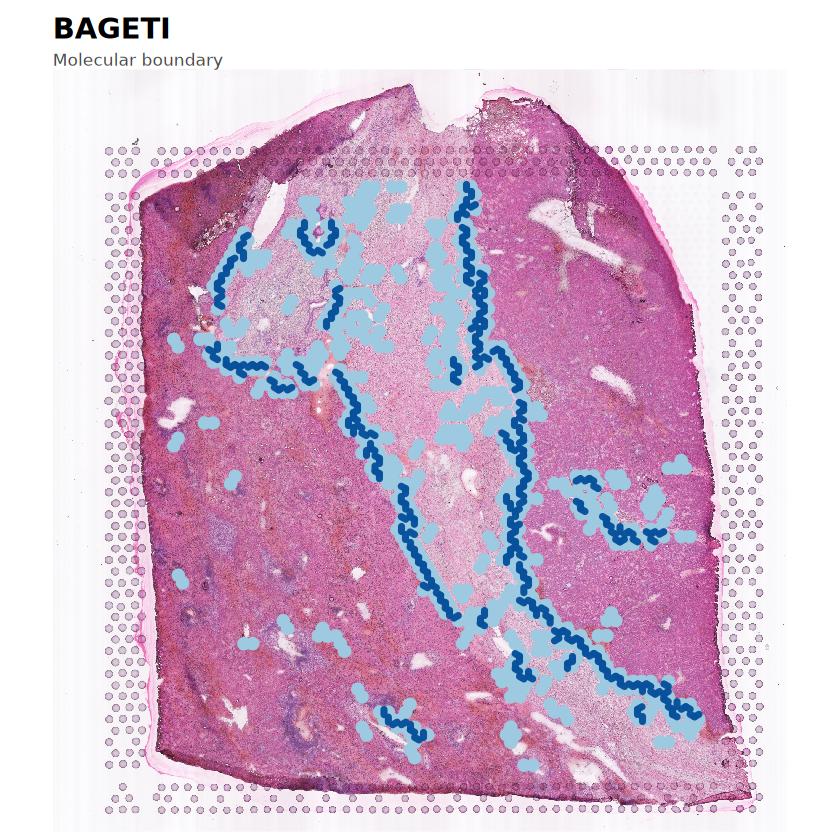

In [17]:
# ==============================================================================
# FINAL H&E visualization
#
# Light-blue dots = real Visium spots belonging to MAIN BAGETI edges
# Dark-blue lines = CLEANED DUAL molecular boundary
#
# IMPORTANT:
#   Spots come from the endpoints of MAIN MAP primal edges.
#   Boundary lines are the cleaned DUAL/Voronoi edges.
# ==============================================================================


# ------------------------------------------------------------------------------
# 17. Recover REAL Visium spots belonging to MAIN BAGETI edges
#
# df_main_primal contains:
#   spot1 = first Visium spot index of each MAIN edge
#   spot2 = second Visium spot index of each MAIN edge
#
# df_map preserves the original df_bg ordering, so spot_index corresponds
# directly to the BAGETI global spot index.
# ------------------------------------------------------------------------------

main_spot_ids <- sort(
  unique(
    c(
      df_main_primal$spot1,
      df_main_primal$spot2
    )
  )
)


df_interface_spots_main <- df_map %>%

  mutate(
    spot_index = seq_len(n())
  ) %>%

  filter(
    spot_index %in% main_spot_ids,
    matched,
    is.finite(x_img),
    is.finite(y_img)
  )


cat(
  "\nMAIN BAGETI edge spots:",
  length(main_spot_ids),
  "\n"
)

cat(
  "MAIN edge spots successfully mapped to H&E:",
  nrow(df_interface_spots_main),
  "\n"
)


# ------------------------------------------------------------------------------
# 18. Check plotting objects
# ------------------------------------------------------------------------------

stopifnot(
  exists("img"),
  exists("img_w"),
  exists("img_h"),
  exists("df_boundary_he"),
  exists("df_interface_spots_main")
)

stopifnot(
  all(
    c(
      "x_img",
      "y_img"
    ) %in%
      names(df_interface_spots_main)
  )
)

stopifnot(
  all(
    c(
      "hx1",
      "hy1",
      "hx2",
      "hy2"
    ) %in%
      names(df_boundary_he)
  )
)


# ------------------------------------------------------------------------------
# 19. Colors
# ------------------------------------------------------------------------------

boundary_color <-
  "#08519C"

interface_color <-
  "#9ECAE1"


# ==============================================================================
# 20. H&E + MAIN spots + CLEANED DUAL boundary
# ==============================================================================

p_final <- ggplot() +

  # --------------------------------------------------------------------------
  # H&E background
  # --------------------------------------------------------------------------

  annotation_raster(
    raster = img,

    xmin = 0,
    xmax = img_w,

    ymin = 0,
    ymax = img_h
  ) +

  # --------------------------------------------------------------------------
  # Real Visium spots belonging to MAIN BAGETI transition edges
  #
  # Draw spots FIRST so the molecular boundary remains visually on top.
  # --------------------------------------------------------------------------

  geom_point(
    data =
      df_interface_spots_main,

    mapping = aes(
      x = x_img,
      y = y_img
    ),

    color =
      interface_color,

    size =
      2.75,

    alpha =
      1
  ) +

  # --------------------------------------------------------------------------
  # CLEANED DUAL molecular boundary
  # --------------------------------------------------------------------------

  geom_segment(
    data =
      df_boundary_he,

    mapping = aes(
      x = hx1,
      y = hy1,
      xend = hx2,
      yend = hy2
    ),

    color =
      boundary_color,

    linewidth =
      1.5,

    alpha =
      0.98,

    lineend =
      "round"
  ) +

  # --------------------------------------------------------------------------
  # Axes / H&E coordinate system
  # --------------------------------------------------------------------------

  scale_x_continuous(
    limits = c(
      0,
      img_w
    ),

    expand = c(
      0,
      0
    )
  ) +

  scale_y_reverse(
    limits = c(
      img_h,
      0
    ),

    expand = c(
      0,
      0
    )
  ) +

  coord_fixed() +

  theme_void() +

  theme(

    plot.title = element_text(
      face = "bold",
      size = 17,
      hjust = 0
    ),

    plot.subtitle = element_text(
      size = 10,
      color = "grey30",
      hjust = 0
    ),

    plot.margin = margin(
      t = 5,
      r = 5,
      b = 5,
      l = 5
    )
  ) +

  labs(
    title =
      "BAGETI",

    subtitle =
      "Molecular boundary"
  )


# ==============================================================================
# 21. Display
# ==============================================================================

print(
  p_final
)


# ==============================================================================
# 22. Save H&E figure
# ==============================================================================

out_png <- file.path(
  output_dir,
  paste0(
    set_name,
    "_MainSpots_CleanedDual_Boundary_on_HE.png"
  )
)

out_pdf <- file.path(
  output_dir,
  paste0(
    set_name,
    "_MainSpots_CleanedDual_Boundary_on_HE.pdf"
  )
)


ggsave(
  filename =
    out_png,

  plot =
    p_final,

  width =
    9,

  height =
    9,

  dpi =
    400,

  bg =
    "white"
)


ggsave(
  filename =
    out_pdf,

  plot =
    p_final,

  width =
    9,

  height =
    9,

  bg =
    "white"
)


# ==============================================================================
# 23. Save the actual MAIN interface spots too
# ==============================================================================

out_spot_rds <- file.path(
  output_dir,
  paste0(
    set_name,
    "_Main_Interface_Spots_HEcoords.rds"
  )
)

saveRDS(
  df_interface_spots_main,
  out_spot_rds
)


# ==============================================================================
# 24. Summary
# ==============================================================================

cat(
  "\n====================================================\n"
)

cat(
  "FINAL H&E visualization completed.\n\n"
)

cat(
  "MAIN BAGETI spots:",
  nrow(df_interface_spots_main),
  "\n"
)

cat(
  "Cleaned DUAL boundary edges:",
  nrow(df_boundary_he),
  "\n\n"
)

cat(
  "PNG:\n",
  out_png,
  "\n\n"
)

cat(
  "PDF:\n",
  out_pdf,
  "\n\n"
)

cat(
  "Spot RDS:\n",
  out_spot_rds,
  "\n"
)

cat(
  "====================================================\n"
)

Warning message:
“package ‘igraph’ was built under R version 4.3.3”

Attaching package: ‘igraph’


The following object is masked from ‘package:tidyr’:

    crossing


The following object is masked from ‘package:FNN’:

    knn


The following objects are masked from ‘package:dplyr’:

    as_data_frame, groups, union


The following object is masked from ‘package:Seurat’:

    components


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union




Cleaned dual boundary segments available: 316 
Boundary anchors: 316 
Estimated anchor spacing: 11.50739 
Connected components: 22 

 9  3 14 10  8  4  6  2 12  1 17  5 15  7 19 20 21 22 11 13 16 18 
58 48 41 31 25 14 13 12 10  9  8  7  7  5  4  4  4  4  3  3  3  3 
Curve 1 | component 2 | anchors: 12 
Curve 2 | component 3 | anchors: 44 
Curve 3 | component 4 | anchors: 14 
Curve 4 | component 6 | anchors: 12 
Curve 5 | component 8 | anchors: 22 
Curve 6 | component 9 | anchors: 48 
Curve 7 | component 10 | anchors: 27 
Curve 8 | component 14 | anchors: 36 
Smoothed curves reconstructed: 8 

Smoothed cleaned-dual boundary completed.

Input cleaned dual segments: 316 
Smoothed curves: 8 

PNG:
 /work/cxz220015/Anaconda/BAGUTTE/case/Case HCC (827)/Barrier_myCAF_BoundaryOnly_on_HE_smoothed.png 

PDF:
 /work/cxz220015/Anaconda/BAGUTTE/case/Case HCC (827)/Barrier_myCAF_BoundaryOnly_on_HE_smoothed.pdf 

Curve RDS:
 /work/cxz220015/Anaconda/BAGUTTE/case/Case HCC (827)/Barrier_myCAF_smoothed_

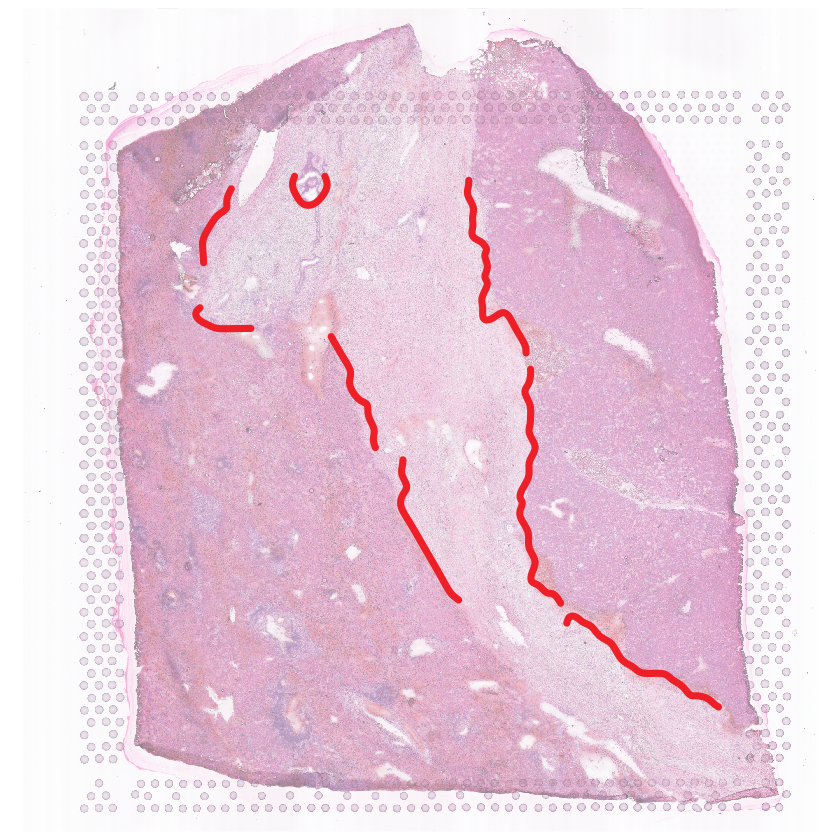

In [20]:
# ==============================================================================
# FINAL H&E visualization — smoothed CLEANED DUAL boundary
#
# INPUT OBJECTS ALREADY CREATED BY THE PREVIOUS BLOCK:
#   img
#   img_w
#   img_h
#   df_boundary_he
#   output_dir
#
# df_boundary_he = cleaned DUAL BAGETI boundary already mapped to H&E coordinates
#
# NO additional RDS is read.
# NO historical df_lines_he is required.
# ==============================================================================

library(ggplot2)
library(dplyr)
library(igraph)


# ------------------------------------------------------------------------------
# 1. Check required in-memory objects
# ------------------------------------------------------------------------------

stopifnot(
  exists("img"),
  exists("img_w"),
  exists("img_h"),
  exists("df_boundary_he"),
  exists("output_dir")
)

stopifnot(
  all(
    c(
      "hx1",
      "hy1",
      "hx2",
      "hy2"
    ) %in%
      names(df_boundary_he)
  )
)

if (nrow(df_boundary_he) < 2) {
  stop(
    "Too few cleaned boundary segments to reconstruct smooth curves."
  )
}

cat(
  "Cleaned dual boundary segments available:",
  nrow(df_boundary_he),
  "\n"
)


# ------------------------------------------------------------------------------
# 2. Fade H&E background
#
# Blend the H&E image toward white.
# Smaller he_strength = lighter background.
# ------------------------------------------------------------------------------

he_strength <- 0.55

img_faded <- img

if (
  is.array(img_faded) &&
  length(dim(img_faded)) == 3
) {

  if (dim(img_faded)[3] >= 3) {

    img_faded[, , 1:3] <-
      he_strength *
      img_faded[, , 1:3] +
      (1 - he_strength)

  } else {

    warning(
      "img does not appear to have RGB channels; using original img."
    )
  }

} else {

  warning(
    "img is not a standard image array; using original img."
  )
}


# ------------------------------------------------------------------------------
# 3. Boundary color
# ------------------------------------------------------------------------------

boundary_color <- "#ED1C24"


# ------------------------------------------------------------------------------
# 4. Build anchor points from CLEANED dual boundary
#
# Each retained dual segment contributes:
#   - one midpoint
#   - one local tangent direction
# ------------------------------------------------------------------------------

df_anchor <- df_boundary_he %>%

  mutate(

    anchor_id =
      seq_len(n()),

    mid_x =
      (hx1 + hx2) / 2,

    mid_y =
      (hy1 + hy2) / 2,

    tx =
      hx2 - hx1,

    ty =
      hy2 - hy1,

    tnorm =
      sqrt(
        tx^2 +
        ty^2
      )
  ) %>%

  filter(
    is.finite(mid_x),
    is.finite(mid_y),
    is.finite(tx),
    is.finite(ty),
    is.finite(tnorm),
    tnorm > 0
  ) %>%

  mutate(

    tx =
      tx / tnorm,

    ty =
      ty / tnorm
  )


cat(
  "Boundary anchors:",
  nrow(df_anchor),
  "\n"
)

if (nrow(df_anchor) < 2) {

  stop(
    "Too few boundary anchors to reconstruct curves."
  )
}


# ------------------------------------------------------------------------------
# 5. Estimate characteristic anchor spacing
# ------------------------------------------------------------------------------

anchor_xy <- as.matrix(
  df_anchor[
    ,
    c(
      "mid_x",
      "mid_y"
    )
  ]
)

D_anchor <- as.matrix(
  dist(anchor_xy)
)

diag(D_anchor) <- Inf


# Ignore duplicate / nearly duplicate positions
D_tmp <- D_anchor

D_tmp[
  D_tmp < 1e-8
] <- Inf


nearest_dist <- apply(
  D_tmp,
  1,
  min,
  na.rm = TRUE
)


anchor_spacing <- median(
  nearest_dist[
    is.finite(nearest_dist)
  ],
  na.rm = TRUE
)


if (
  !is.finite(anchor_spacing) ||
  anchor_spacing <= 0
) {

  stop(
    "Failed to estimate anchor spacing."
  )
}


cat(
  "Estimated anchor spacing:",
  anchor_spacing,
  "\n"
)


# ------------------------------------------------------------------------------
# 6. Build orientation-aware graph
#
# Connect two boundary anchors only when:
#   1. they are spatially close;
#   2. their connecting vector approximately follows both local tangents;
#   3. their local tangent directions are compatible.
# ------------------------------------------------------------------------------

connect_radius <-
  2.7 *
  anchor_spacing

max_connector_angle <-
  75

max_tangent_angle <-
  85


connector_threshold <- cos(
  max_connector_angle *
    pi / 180
)

tangent_threshold <- cos(
  max_tangent_angle *
    pi / 180
)


edge_list <- list()

edge_counter <- 0L

n_anchor <- nrow(
  df_anchor
)


if (n_anchor >= 2) {

  for (
    i in seq_len(
      n_anchor - 1
    )
  ) {

    for (
      j in (i + 1):n_anchor
    ) {

      dx <-
        df_anchor$mid_x[j] -
        df_anchor$mid_x[i]

      dy <-
        df_anchor$mid_y[j] -
        df_anchor$mid_y[i]

      gap <-
        sqrt(
          dx^2 +
          dy^2
        )


      if (
        !is.finite(gap) ||
        gap <= 0 ||
        gap > connect_radius
      ) {
        next
      }


      ux <-
        dx / gap

      uy <-
        dy / gap


      align_i <- abs(
        ux *
          df_anchor$tx[i] +
          uy *
          df_anchor$ty[i]
      )


      align_j <- abs(
        ux *
          df_anchor$tx[j] +
          uy *
          df_anchor$ty[j]
      )


      tangent_agreement <- abs(
        df_anchor$tx[i] *
          df_anchor$tx[j] +
          df_anchor$ty[i] *
          df_anchor$ty[j]
      )


      if (
        align_i >= connector_threshold &&
        align_j >= connector_threshold &&
        tangent_agreement >= tangent_threshold
      ) {

        edge_counter <-
          edge_counter + 1L


        edge_list[[edge_counter]] <-
          data.frame(

            from =
              as.character(
                df_anchor$anchor_id[i]
              ),

            to =
              as.character(
                df_anchor$anchor_id[j]
              ),

            weight =
              gap,

            stringsAsFactors =
              FALSE
          )
      }
    }
  }
}


if (length(edge_list) == 0) {

  stop(
    paste0(
      "No graph edges found. ",
      "Try increasing connect_radius."
    )
  )
}


df_graph_edges <- bind_rows(
  edge_list
)


g_boundary <- graph_from_data_frame(

  d =
    df_graph_edges,

  directed =
    FALSE,

  vertices =
    data.frame(
      name =
        as.character(
          df_anchor$anchor_id
        )
    )
)


comp <-
  components(
    g_boundary
  )$membership


df_anchor$component <-
  comp[
    as.character(
      df_anchor$anchor_id
    )
  ]


cat(
  "Connected components:",
  length(
    unique(
      df_anchor$component
    )
  ),
  "\n"
)

print(
  sort(
    table(
      df_anchor$component
    ),
    decreasing = TRUE
  )
)


# ------------------------------------------------------------------------------
# 7. Reconstruct one smooth curve per component
#
# For each component:
#
#   proximity/orientation graph
#       ->
#   minimum spanning tree
#       ->
#   longest path through tree
#       ->
#   smoothing spline
# ------------------------------------------------------------------------------

min_curve_points <-
  10

spline_spar <-
  0.40


curve_list <- list()

curve_counter <- 0L


component_ids <- sort(
  unique(
    df_anchor$component
  )
)


for (comp_id in component_ids) {


  comp_anchor <- df_anchor %>%

    filter(
      component ==
        comp_id
    )


  if (
    nrow(comp_anchor) <
    min_curve_points
  ) {
    next
  }


  vids <- as.character(
    comp_anchor$anchor_id
  )


  g_sub <- induced_subgraph(
    g_boundary,
    vids = vids
  )


  if (
    ecount(g_sub) == 0
  ) {
    next
  }


  # --------------------------------------------------------------------------
  # Minimum spanning tree
  # --------------------------------------------------------------------------

  g_tree <- mst(
    g_sub,
    weights =
      E(g_sub)$weight
  )


  # --------------------------------------------------------------------------
  # Find diameter / longest weighted path
  # --------------------------------------------------------------------------

  dist_tree <- distances(
    g_tree,
    weights =
      E(g_tree)$weight
  )


  finite_vals <-
    dist_tree[
      is.finite(
        dist_tree
      )
    ]


  if (
    length(finite_vals) == 0
  ) {
    next
  }


  idx_max <- which(
    dist_tree ==
      max(
        finite_vals
      ),
    arr.ind = TRUE
  )


  if (
    nrow(idx_max) == 0
  ) {
    next
  }


  idx_max <-
    idx_max[
      1,
      ,
      drop = FALSE
    ]


  start_v <-
    rownames(
      dist_tree
    )[
      idx_max[1, 1]
    ]


  end_v <-
    colnames(
      dist_tree
    )[
      idx_max[1, 2]
    ]


  sp <- shortest_paths(

    g_tree,

    from =
      start_v,

    to =
      end_v,

    weights =
      E(g_tree)$weight,

    output =
      "vpath"
  )


  path_ids <- as.integer(
    as_ids(
      sp$vpath[[1]]
    )
  )


  # Keep only actual anchor IDs.
  # Do NOT assume anchor_id == current row number.
  path_ids <- path_ids[
    is.finite(path_ids) &
      path_ids %in%
        df_anchor$anchor_id
  ]


  if (
    length(path_ids) <
    min_curve_points
  ) {
    next
  }


  ordered_pts <- df_anchor %>%

    filter(
      anchor_id %in%
        path_ids
    ) %>%

    mutate(
      path_order =
        match(
          anchor_id,
          path_ids
        )
    ) %>%

    arrange(
      path_order
    ) %>%

    filter(
      is.finite(mid_x),
      is.finite(mid_y)
    )


  if (
    nrow(ordered_pts) <
    min_curve_points
  ) {
    next
  }


  # --------------------------------------------------------------------------
  # Arc-length parameterization
  # --------------------------------------------------------------------------

  step_len <- sqrt(

    diff(
      ordered_pts$mid_x
    )^2 +

      diff(
        ordered_pts$mid_y
      )^2
  )


  if (
    any(
      !is.finite(
        step_len
      )
    )
  ) {
    next
  }


  s <- c(
    0,
    cumsum(
      step_len
    )
  )


  keep_unique <-
    is.finite(s) &
    !duplicated(s) &
    is.finite(
      ordered_pts$mid_x
    ) &
    is.finite(
      ordered_pts$mid_y
    )


  s <-
    s[
      keep_unique
    ]


  ordered_pts <-
    ordered_pts[
      keep_unique,
      ,
      drop = FALSE
    ]


  if (
    length(s) <
    min_curve_points
  ) {
    next
  }


  # --------------------------------------------------------------------------
  # Smooth x(s) and y(s)
  #
  # Use distinct names so we do NOT overwrite the earlier affine fit_x / fit_y.
  # --------------------------------------------------------------------------

  spline_fit_x <- smooth.spline(
    x = s,
    y =
      ordered_pts$mid_x,
    spar =
      spline_spar
  )


  spline_fit_y <- smooth.spline(
    x = s,
    y =
      ordered_pts$mid_y,
    spar =
      spline_spar
  )


  s_dense <- seq(
    min(s),
    max(s),
    length.out =
      max(
        200,
        length(s) * 25
      )
  )


  pred_x <- predict(
    spline_fit_x,
    s_dense
  )$y


  pred_y <- predict(
    spline_fit_y,
    s_dense
  )$y


  valid_pred <-
    is.finite(pred_x) &
    is.finite(pred_y)


  pred_x <-
    pred_x[
      valid_pred
    ]


  pred_y <-
    pred_y[
      valid_pred
    ]


  s_dense <-
    s_dense[
      valid_pred
    ]


  if (
    length(pred_x) < 2
  ) {
    next
  }


  curve_counter <-
    curve_counter + 1L


  curve_list[[curve_counter]] <-
    data.frame(

      curve_id =
        curve_counter,

      component =
        comp_id,

      s =
        s_dense,

      x =
        pred_x,

      y =
        pred_y
    )


  cat(
    "Curve",
    curve_counter,
    "| component",
    comp_id,
    "| anchors:",
    nrow(
      ordered_pts
    ),
    "\n"
  )
}


if (
  length(curve_list) == 0
) {

  stop(
    "No smooth curves were reconstructed."
  )
}


df_boundary_curve <- bind_rows(
  curve_list
)


cat(
  "Smoothed curves reconstructed:",
  length(
    unique(
      df_boundary_curve$curve_id
    )
  ),
  "\n"
)


# ------------------------------------------------------------------------------
# 8. Build final figure
#
# Faded H&E + smoothed cleaned dual boundary
# ------------------------------------------------------------------------------

p_final <- ggplot() +

  annotation_raster(
    raster =
      img_faded,

    xmin =
      0,

    xmax =
      img_w,

    ymin =
      0,

    ymax =
      img_h
  ) +

  geom_path(
    data =
      df_boundary_curve,

    aes(
      x =
        x,

      y =
        y,

      group =
        curve_id
    ),

    color =
      boundary_color,

    linewidth =
      1.5,

    alpha =
      0.98,

    lineend =
      "round",

    linejoin =
      "round"
  ) +

  scale_x_continuous(
    limits =
      c(
        0,
        img_w
      ),

    expand =
      c(
        0,
        0
      )
  ) +

  scale_y_reverse(
    limits =
      c(
        img_h,
        0
      ),

    expand =
      c(
        0,
        0
      )
  ) +

  coord_fixed() +

  theme_void() +

  theme(

    plot.title =
      element_text(
        face =
          "bold",
        size =
          17,
        hjust =
          0
      ),

    plot.margin =
      margin(
        t = 5,
        r = 5,
        b = 5,
        l = 5
      )
  )


# ------------------------------------------------------------------------------
# 9. Display
# ------------------------------------------------------------------------------

print(
  p_final
)


# ------------------------------------------------------------------------------
# 10. Save
# ------------------------------------------------------------------------------

out_png <- file.path(
  output_dir,
  "Barrier_myCAF_BoundaryOnly_on_HE_smoothed.png"
)

out_pdf <- file.path(
  output_dir,
  "Barrier_myCAF_BoundaryOnly_on_HE_smoothed.pdf"
)

out_curve_rds <- file.path(
  output_dir,
  "Barrier_myCAF_smoothed_boundary_curve.rds"
)


# This RDS is an OUTPUT of this block, not an input dependency.
saveRDS(
  df_boundary_curve,
  out_curve_rds
)


ggsave(
  filename =
    out_png,

  plot =
    p_final,

  width =
    9,

  height =
    9,

  dpi =
    400,

  bg =
    "white"
)


ggsave(
  filename =
    out_pdf,

  plot =
    p_final,

  width =
    9,

  height =
    9,

  bg =
    "white"
)


cat(
  "\n============================================\n"
)

cat(
  "Smoothed cleaned-dual boundary completed.\n\n"
)

cat(
  "Input cleaned dual segments:",
  nrow(df_boundary_he),
  "\n"
)

cat(
  "Smoothed curves:",
  length(
    unique(
      df_boundary_curve$curve_id
    )
  ),
  "\n\n"
)

cat(
  "PNG:\n",
  out_png,
  "\n\n"
)

cat(
  "PDF:\n",
  out_pdf,
  "\n\n"
)

cat(
  "Curve RDS:\n",
  out_curve_rds,
  "\n"
)

cat(
  "============================================\n"
)